#Polynomial curve fitting (ML vs MAP/Regularized)

**Goal**

Reproduce the polynomial fitting (ML vs MAP/Regularized) like Bishop's book Figures 1.4–1.7 using numpy, matplotlib, and optionally scikit-learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# For nice plots
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [2]:
def generate_data(N=10, noise_std=0.3, seed=42):
    np.random.seed(seed)
    x = np.linspace(0, 1, N)
    t = np.sin(2 * np.pi * x) + noise_std * np.random.randn(N)
    return x.reshape(-1, 1), t.reshape(-1, 1)

x_train, t_train = generate_data(N=10, noise_std=0.3)
x_plot = np.linspace(0, 1, 100).reshape(-1, 1)
true_y = np.sin(2 * np.pi * x_plot)

print("Data generated!")

Data generated!


In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge

def fit_polynomial_ML(x, t, degree=3):
    """Maximum Likelihood = Ordinary Least Squares"""
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(x)
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, t)
    return model, poly

def fit_polynomial_MAP(x, t, degree=3, alpha=1e-3):
    """MAP with Gaussian prior = Ridge Regression"""
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(x)
    # alpha here is regularization strength (lambda)
    model = Ridge(alpha=alpha, fit_intercept=False)
    model.fit(X_poly, t)
    return model, poly

def predict(model, poly, x):
    X_poly = poly.transform(x)
    return model.predict(X_poly)

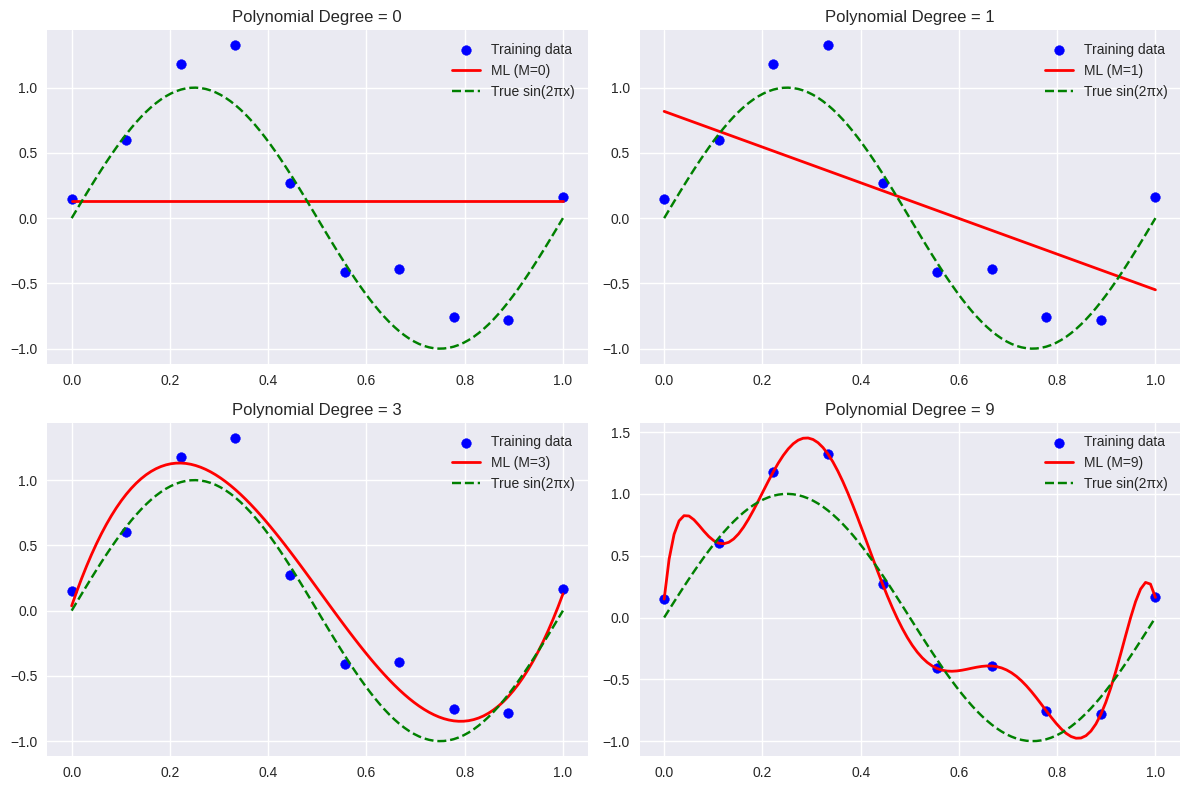

In [4]:
degrees = [0, 1, 3, 9]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, d in enumerate(degrees):
    model, poly = fit_polynomial_ML(x_train, t_train, degree=d)
    y_pred = predict(model, poly, x_plot)

    ax = axes[i]
    ax.scatter(x_train, t_train, color='blue', label='Training data')
    ax.plot(x_plot, y_pred, 'r-', linewidth=2, label=f'ML (M={d})')
    ax.plot(x_plot, true_y, 'g--', label='True sin(2πx)')
    ax.set_title(f'Polynomial Degree = {d}')
    ax.legend()

plt.tight_layout()
plt.savefig('Figure_1-4.png', dpi=200, bbox_inches='tight')
plt.show()

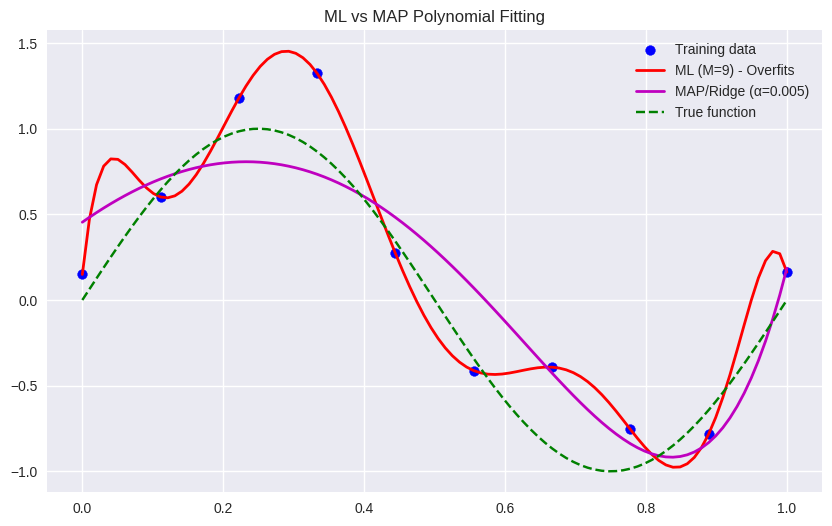

In [14]:
degree = 9
alpha = 0.005  # Tune this (regularization strength) 0.002

# ML
model_ml, poly_ml = fit_polynomial_ML(x_train, t_train, degree)
y_ml = predict(model_ml, poly_ml, x_plot)

# MAP / Ridge
model_map, poly_map = fit_polynomial_MAP(x_train, t_train, degree, alpha=alpha)
y_map = predict(model_map, poly_map, x_plot)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, t_train, color='blue', label='Training data')
plt.plot(x_plot, y_ml, 'r-', linewidth=2, label=f'ML (M={degree}) - Overfits')
plt.plot(x_plot, y_map, 'm-', linewidth=2, label=f'MAP/Ridge (α={alpha})')
plt.plot(x_plot, true_y, 'g--', label='True function')
plt.title('ML vs MAP Polynomial Fitting')
plt.legend()
plt.grid(True)
plt.savefig('polynomial_fitting_ML_VS_MAP.png', dpi=200, bbox_inches='tight')
plt.show()

##How to Tune & Experiment

- Increase alpha in MAP → smoother curve (stronger regularization).
- Try different noise_std and N.
- For more figures (like effect of regularization), loop over several alpha values.